In [1]:
###############################################################################
# CHAPTER 3: FORECASTING PRINCIPLES & PRACTICE — PYTHON (COMPLETE SCRIPT)
###############################################################################

# =========================
# 0. INSTALL DEPENDENCIES
# =========================
import sys
!{sys.executable} -m pip install numpy pandas matplotlib seaborn statsforecast utilsforecast fpppy ipywidgets openpyxl
!{sys.executable} -m pip install statsforecast --only-binary=:all:

In [2]:

# =========================
# 1. GLOBAL SETTINGS
# =========================
import warnings
warnings.filterwarnings(
    "ignore",
    category=UserWarning,
    message=".*FigureCanvasAgg is non-interactive.*"
)

import os
os.environ["NIXTLA_ID_AS_COL"] = "true"

import numpy as np
np.set_printoptions(suppress=True)
np.random.seed(1)

import random
random.seed(1)

import pandas as pd
pd.set_option("max_colwidth", 100)
pd.set_option("display.precision", 3)

# =========================
# 2. PLOTTING STYLE (FPP)
# =========================

import statsmodels.api as sm

import seaborn as sns
sns.set_style("whitegrid")

import matplotlib.pyplot as plt
plt.style.use("ggplot")

plt.rcParams.update({
    "figure.figsize": (8, 5),
    "figure.dpi": 100,
    "savefig.dpi": 300,
    "figure.constrained_layout.use": True,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "legend.title_fontsize": 10,
})

import matplotlib as mpl
from cycler import cycler
mpl.rcParams['axes.prop_cycle'] = cycler(color=["#000000", "#2f2fff"])


In [3]:
# =========================
# 3. LIBRARY IMPORTS
# =========================

from statsforecast import StatsForecast
from utilsforecast.plotting import plot_series
import calendar
from coreforecast.scalers import boxcox, boxcox_lambda
from statsmodels.tsa.seasonal import STL, seasonal_decompose

from pathlib import Path

C:\Users\HP\AppData\Local\Temp\ipykernel_10036\2841540081.py:40: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


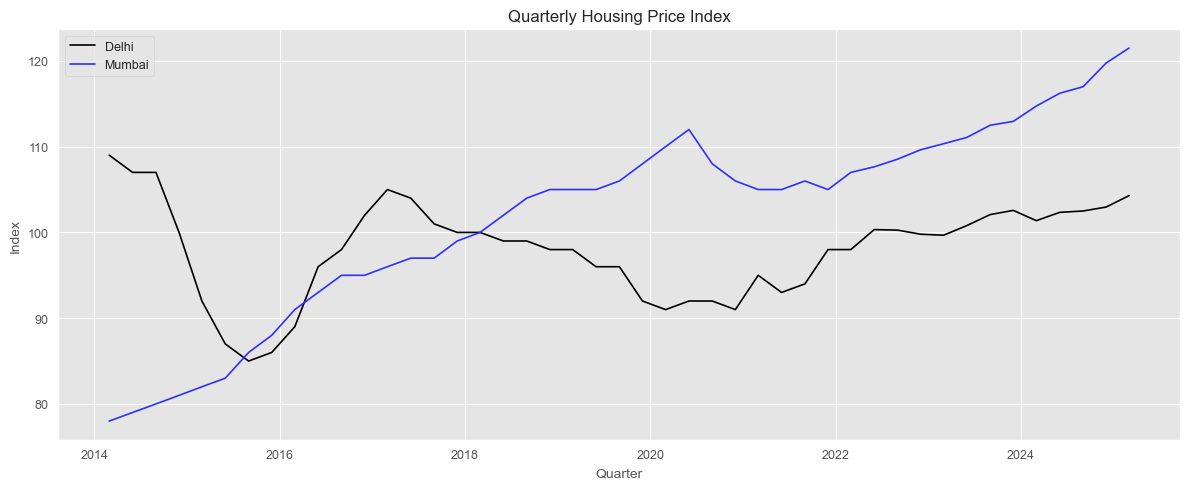

In [4]:
########################################################## Fig. Quarterly HPI ######################################################
###################### Data Source : NHB | Housing price index for Delhi, mumbai using index from NHB.##############################

import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# LOAD DATA
# ------------------------------------------------------------
#data_dir = Path("/Users/satyendragupta/Library/CloudStorage/OneDrive-econdse.org/Documents/_Teaching/Forecasting/data")
#fig_dir  = Path("/Users/satyendragupta/Library/CloudStorage/OneDrive-econdse.org/Documents/_Teaching/Forecasting/figures")

data_dir = Path("C:/Users/HP/OneDrive - econdse.org/Documents/_Teaching/Forecasting/data")
fig_dir  = Path("C:/Users/HP/OneDrive - econdse.org/Documents/_Teaching/Forecasting/figures")


file_path = data_dir / "quart_housing_price_index_2014_2025.xlsx"

df = pd.read_excel(file_path)

# ------------------------------------------------------------
# DATE HANDLING
# ------------------------------------------------------------
df['ds'] = pd.to_datetime(df['ds'])
df = df.sort_values('ds')

# ------------------------------------------------------------
# PLOT 
# ------------------------------------------------------------
plt.figure(figsize=(12, 5))

plt.plot(df['ds'], df['delhi_HPI'], linewidth=1.2, label='Delhi')
plt.plot(df['ds'], df['mumbai_HPI'], linewidth=1.2, label='Mumbai')

plt.title("Quarterly Housing Price Index")
plt.xlabel("Quarter")
plt.ylabel("Index")

plt.legend()
plt.tight_layout()
plt.show()


C:\Users\HP\AppData\Local\Temp\ipykernel_10036\195873833.py:53: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


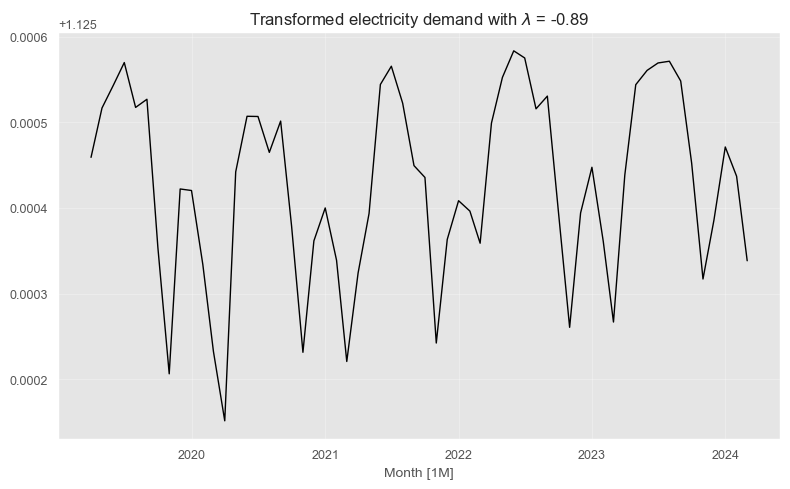

In [6]:
########################################################## Fig. 3.2 ######################################################

# =========================
# IMPORTS
# =========================
import pandas as pd
import matplotlib.pyplot as plt
from coreforecast.scalers import boxcox, boxcox_lambda

# =========================
# LOAD DATA
# =========================
data_dir = Path("C:/Users/HP/OneDrive - econdse.org/Documents/_Teaching/Forecasting/data")
fig_dir  = Path("C:/Users/HP/OneDrive - econdse.org/Documents/_Teaching/Forecasting/figures")

df = pd.read_excel(data_dir / "delhi_monthly_electricity_demand_2020_2024.xlsx", parse_dates=["ds"])

# =========================
# BOX-COX TRANSFORMATION (GUERRERO)
# =========================
y = df["electricity_demand"].to_numpy()

optim_lambda = boxcox_lambda(
    y,
    method="guerrero",
    season_length=12   # MONTHLY data → annual seasonality
)

y_bc = boxcox(y, optim_lambda)

# =========================
# PLOT
# =========================
plt.figure(figsize=(8, 5))

plt.plot(
    df["ds"],
    y_bc,
    color="black",
    linewidth=1
)

plt.title(
    rf"Transformed electricity demand with $\lambda$ = {optim_lambda:.2f}",
    fontsize=12
)
plt.xlabel("Month [1M]")
plt.ylabel("")

# Light grid like FPP
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(fig_dir / "fig_03_02.png", dpi=300, bbox_inches="tight")
plt.show()


C:\Users\HP\AppData\Local\Temp\ipykernel_28800\3173732121.py:27: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


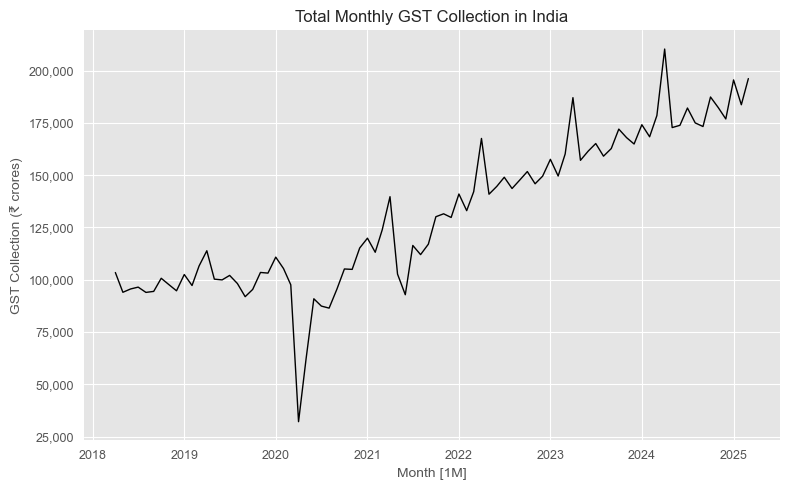

In [13]:
############################################# Fig. 3.3 #########################################################

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Load data
data_dir = Path("C:/Users/HP/OneDrive - econdse.org/Documents/_Teaching/Forecasting/data")
fig_dir  = Path("C:/Users/HP/OneDrive - econdse.org/Documents/_Teaching/Forecasting/figures")

df = pd.read_excel(data_dir / "monthly_total_GST_2018_2025.xlsx")
df["ds"] = pd.to_datetime(df["ds"], dayfirst=True)

# Plot
fig, ax = plt.subplots()
ax.plot(df["ds"], df["Total_GST (in crores)"], color="black", lw=1)

ax.set(
    title="Total Monthly GST Collection in India",
    xlabel="Month [1M]",
    ylabel="GST Collection (₹ crores)"
)
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}')) 
for s in ax.spines.values():
    s.set_visible(False)

plt.tight_layout()
plt.savefig(fig_dir / "fig_03_03.png", dpi=300, bbox_inches="tight")
plt.show()


C:\Users\HP\AppData\Local\Temp\ipykernel_28800\2445495406.py:50: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


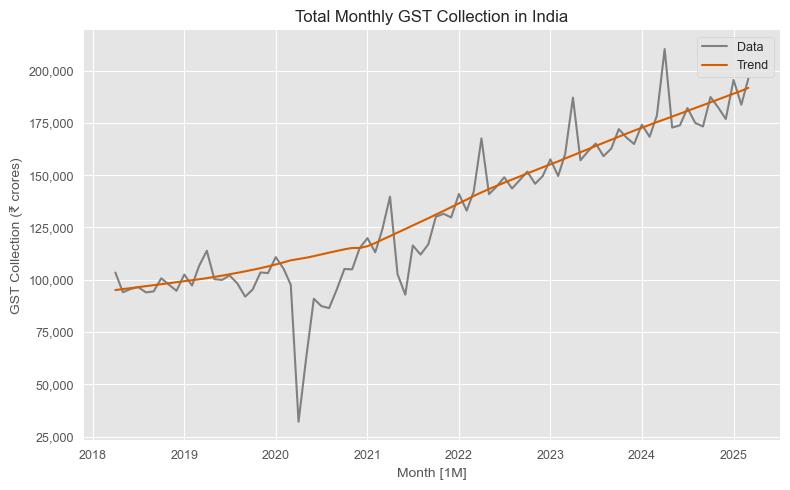

In [14]:
############################################# Fig. 3.4 #########################################################

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import STL
import matplotlib.ticker as mtick ## for adding commas
# ------------------------------------------------------------
# Load data
# ------------------------------------------------------------
data_dir = Path("C:/Users/HP/OneDrive - econdse.org/Documents/_Teaching/Forecasting/data")
fig_dir  = Path("C:/Users/HP/OneDrive - econdse.org/Documents/_Teaching/Forecasting/figures")

df = pd.read_excel(data_dir / "monthly_total_GST_2018_2025.xlsx")

df["ds"] = pd.to_datetime(df["ds"], dayfirst=True)
df = df.sort_values("ds")

# ------------------------------------------------------------
# STL decomposition (trend)
# ------------------------------------------------------------
stl = STL(df["Total_GST (in crores)"], period=12, robust=True)
res = stl.fit()

dcmp = pd.DataFrame({
    "ds": df["ds"],
    "data": df["Total_GST (in crores)"],
    "trend": res.trend
})

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

fig, ax = plt.subplots()

sns.lineplot(data=dcmp, x="ds", y="data", color="gray", label="Data", ax=ax)
sns.lineplot(data=dcmp, x="ds", y="trend", color="#D55E00", label="Trend", ax=ax)

ax.set(
    title="Total Monthly GST Collection in India",
    xlabel="Month [1M]",
    ylabel="GST Collection (₹ crores)"
)
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}')) ## for adding commas 

for s in ax.spines.values():
    s.set_visible(False)

plt.tight_layout()
plt.savefig(fig_dir / "fig_03_04.png", dpi=300, bbox_inches="tight")
plt.show()


C:\Users\HP\AppData\Local\Temp\ipykernel_28800\3266463345.py:59: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


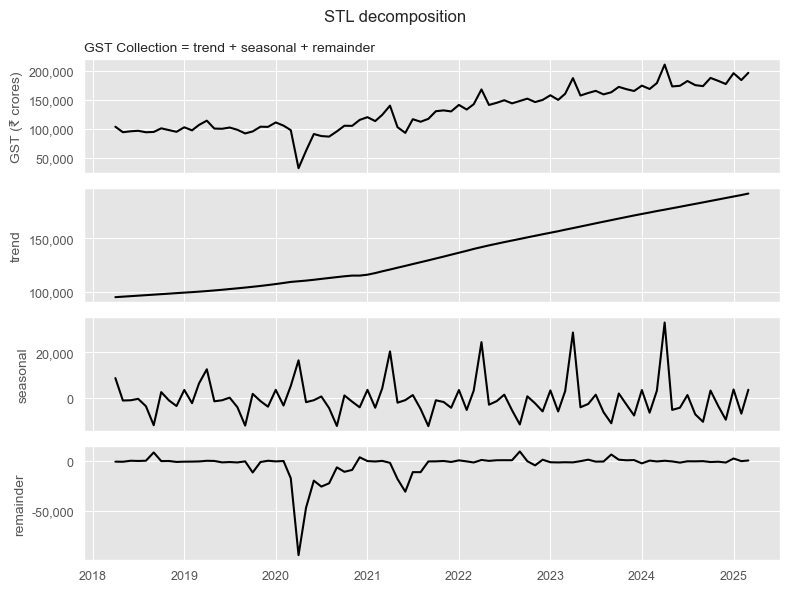

In [15]:
############################################# Fig. 3.5 #########################################################

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick
from statsmodels.tsa.seasonal import STL

# ------------------------------------------------------------
# Load data
# ------------------------------------------------------------
data_dir = Path("C:/Users/HP/OneDrive - econdse.org/Documents/_Teaching/Forecasting/data")
fig_dir  = Path("C:/Users/HP/OneDrive - econdse.org/Documents/_Teaching/Forecasting/figures")

df = pd.read_excel(data_dir / "monthly_total_GST_2018_2025.xlsx")

df["ds"] = pd.to_datetime(df["ds"], dayfirst=True)
df = df.sort_values("ds")

# ------------------------------------------------------------
# STL decomposition
# ------------------------------------------------------------
stl = STL(df["Total_GST (in crores)"], period=12, robust=True)
res = stl.fit()

dcmp = pd.DataFrame({
    "ds": df["ds"],
    "data": df["Total_GST (in crores)"],
    "trend": res.trend,
    "seasonal": res.seasonal,
    "remainder": res.resid
})

# ------------------------------------------------------------
# Plot 
# ------------------------------------------------------------
fig, axes = plt.subplots(4, 1, sharex=True, figsize=(8, 6))

sns.lineplot(data=dcmp, x="ds", y="data", ax=axes[0], color="black")
sns.lineplot(data=dcmp, x="ds", y="trend", ax=axes[1], color="black")
sns.lineplot(data=dcmp, x="ds", y="seasonal", ax=axes[2], color="black")
sns.lineplot(data=dcmp, x="ds", y="remainder", ax=axes[3], color="black")

axes[0].set_title(
    "GST Collection = trend + seasonal + remainder",
    size="medium",
    loc="left"
)

axes[0].set(ylabel="GST (₹ crores)")
axes[1].set(ylabel="trend")
axes[2].set(ylabel="seasonal")
axes[3].set(ylabel="remainder", xlabel="")

for ax in axes:
    ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

fig.suptitle("STL decomposition")
plt.tight_layout()
plt.savefig(fig_dir / "fig_03_05.png", dpi=300, bbox_inches="tight")
plt.show()


C:\Users\HP\AppData\Local\Temp\ipykernel_28800\20038328.py:58: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


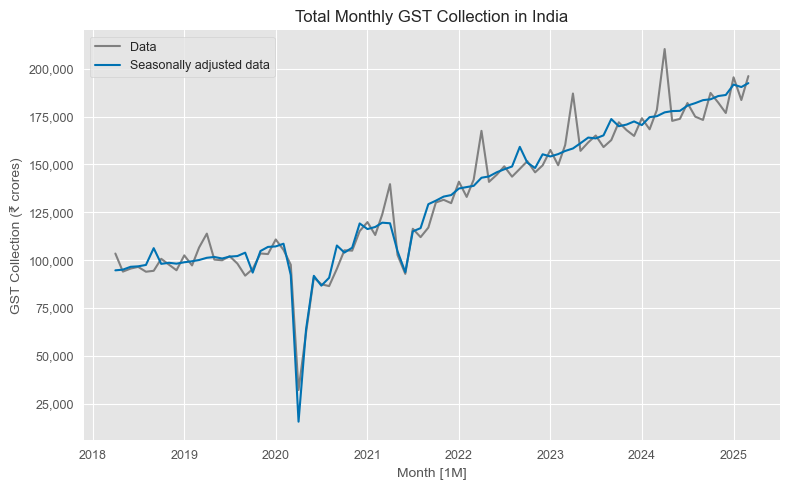

In [16]:
############################################# Fig. 3.6 #########################################################

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import STL
import matplotlib.ticker as mtick

# ------------------------------------------------------------
# Load data
# ------------------------------------------------------------
data_dir = Path("C:/Users/HP/OneDrive - econdse.org/Documents/_Teaching/Forecasting/data")
fig_dir  = Path("C:/Users/HP/OneDrive - econdse.org/Documents/_Teaching/Forecasting/figures")

df = pd.read_excel(data_dir / "monthly_total_GST_2018_2025.xlsx")
df["ds"] = pd.to_datetime(df["ds"], dayfirst=True)
df = df.sort_values("ds")

# ------------------------------------------------------------
# STL decomposition
# ------------------------------------------------------------
stl = STL(df["Total_GST (in crores)"], period=12, robust=True)
res = stl.fit()

dcmp = pd.DataFrame({
    "ds": df["ds"],
    "data": df["Total_GST (in crores)"],
    "seasonal": res.seasonal
})

# ------------------------------------------------------------
# Seasonally adjusted series
# ------------------------------------------------------------
df_sa = dcmp.assign(adj=lambda x: x["data"] - x["seasonal"])

# ------------------------------------------------------------
# Plot (FPP Figure 3.6 style)
# ------------------------------------------------------------
fig, ax = plt.subplots()

sns.lineplot(data=df_sa, x="ds", y="data",
             color="gray", label="Data", ax=ax)

sns.lineplot(data=df_sa, x="ds", y="adj",
             color="#0072B2", label="Seasonally adjusted data", ax=ax)

ax.set(
    title="Total Monthly GST Collection in India",
    xlabel="Month [1M]",
    ylabel="GST Collection (₹ crores)"
)

ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

for s in ax.spines.values():
    s.set_visible(False)

plt.tight_layout()
plt.savefig(fig_dir / "fig_03_06.png", dpi=300, bbox_inches="tight")
plt.show()



C:\Users\HP\AppData\Local\Temp\ipykernel_28800\4206644991.py:25: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


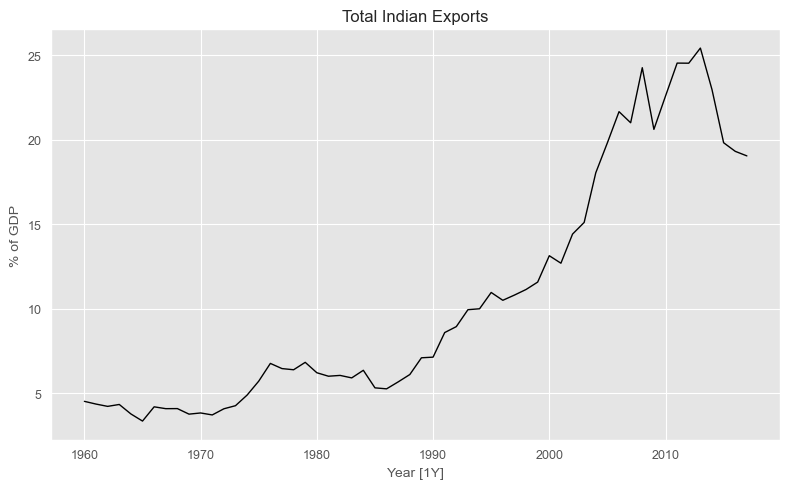

In [17]:
############################################# Fig. 3.7 #########################################################

import pandas as pd
import matplotlib.pyplot as plt

# Load data
data_dir = Path("C:/Users/HP/OneDrive - econdse.org/Documents/_Teaching/Forecasting/data")
fig_dir  = Path("C:/Users/HP/OneDrive - econdse.org/Documents/_Teaching/Forecasting/figures")

global_economy = pd.read_csv(data_dir / "global_economy.csv")

df = global_economy.loc[lambda x: x["unique_id"] == "India"]


fig, ax = plt.subplots()

ax.plot(df["ds"], df["Exports"], color="black", lw=1)

ax.set(
    title="Total Indian Exports",
    xlabel="Year [1Y]",
    ylabel="% of GDP"
)

plt.tight_layout()
plt.savefig(fig_dir / "fig_03_07.png", dpi=300, bbox_inches="tight")
plt.show()


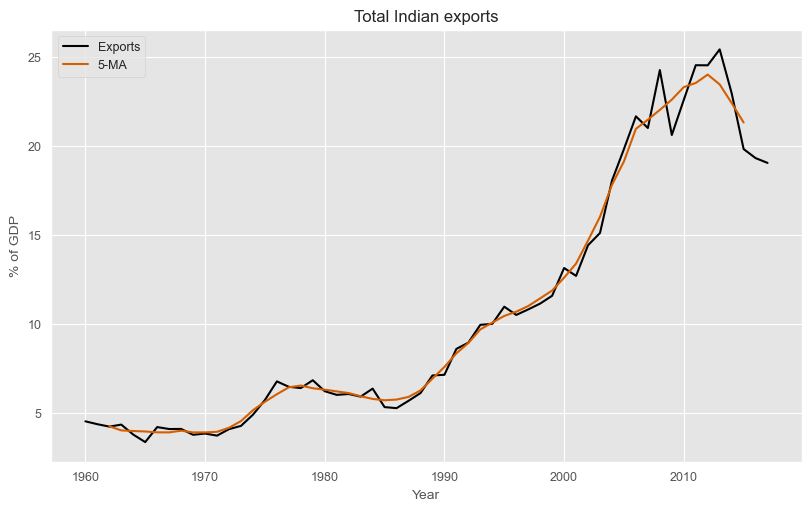

In [11]:
############################################# Fig. 3.8 #########################################################

ind_exports = (
    global_economy
    .loc[lambda x: x["unique_id"] == "India"]
    .assign(MA_5=lambda x: x["Exports"].rolling(5, center=True).mean())
)

fig, ax = plt.subplots()

sns.lineplot(data=ind_exports, x="ds", y="Exports",
             color="black", label="Exports")

sns.lineplot(data=ind_exports, x="ds", y="MA_5",
             color="#D55E00", label="5-MA")

ax.set(
    title="Total Indian exports",
    xlabel="Year",
    ylabel="% of GDP",
)

plt.savefig(fig_dir / "fig_03_08.png", dpi=300, bbox_inches="tight")
plt.show()

